<a href="https://colab.research.google.com/github/zmzain/zmzain/blob/main/AraBERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys
if 'tokenizers' in sys.modules:
    del sys.modules['tokenizers']
if 'transformers' in sys.modules:
    del sys.modules['transformers']


In [2]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback

# --- Config ---
CSV_PATH = "https://raw.githubusercontent.com/zmzain/zmzain/89462097da8cf598cf5e1ddfc2853c4a088f3d49/data1.csv"
TEXT_COL = "Text"
LABEL_COL = "class"
MODEL_NAME = "aubmindlab/bert-base-arabertv02"
MAX_LENGTH = 256
BATCH_SIZE = 16
EVAL_BATCH = 32
LR = 2e-5
EPOCHS = 8
OUTPUT_DIR = "./arabert_train"
EARLY_STOPPING_PATIENCE = 2
SEED = 42

# --- Load data ---
df = pd.read_csv(CSV_PATH)

# map labels to ints
if df[LABEL_COL].dtype == object:
    labels_list = sorted(df[LABEL_COL].unique())
    label2id = {l: i for i, l in enumerate(labels_list)}
    id2label = {i: l for l, i in label2id.items()}
    df["label_id"] = df[LABEL_COL].map(label2id)
else:
    df["label_id"] = df[LABEL_COL].astype(int)
    labels_list = sorted(df["label_id"].unique())
    id2label = {i: str(i) for i in labels_list}
    label2id = {v: v for v in labels_list}

n_labels = len(label2id)

# --- Splits ---
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["label_id"], random_state=SEED)
train_df, val_df = train_test_split(train_df, test_size=0.125, stratify=train_df["label_id"], random_state=SEED)

# --- Tokenizer ---
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, do_lower_case=False)

def to_hf_dataset(df_sub):
    enc = tokenizer(list(df_sub[TEXT_COL].astype(str).values),
                    truncation=True, padding="max_length", max_length=MAX_LENGTH)
    enc["labels"] = list(df_sub["label_id"].values)
    return Dataset.from_dict(enc)

train_ds = to_hf_dataset(train_df)
val_ds = to_hf_dataset(val_df)
test_ds = to_hf_dataset(test_df)

# --- Class weights ---
y_train = train_df["label_id"].values
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/381 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [3]:
# --- Model ---
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=n_labels)

# --- Custom Trainer to use class weights in loss ---
class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights.to(self.model.device) if class_weights is not None else None

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        # forward (without labels) to get logits
        outputs = model(**{k: v for k, v in inputs.items() if k != "labels"})
        logits = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

In [4]:
# --- Metrics (sklearn) ---
def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    labels = p.label_ids
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
    return {"macro_precision": precision, "macro_recall": recall, "macro_f1": f1}



In [5]:
# --- Training args and trainer ---
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=LR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    logging_steps=50,
    save_total_limit=3,
    seed=SEED,
    fp16=torch.cuda.is_available()
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)],
    class_weights=class_weights
)

In [6]:
# --- Train ---
trainer.train()


Epoch,Training Loss,Validation Loss,Macro Precision,Macro Recall,Macro F1
1,0.445884,0.503022,0.773902,0.822178,0.775020
2,0.335619,0.452317,0.827401,0.834302,0.829617
3,0.220100,0.650034,0.842029,0.812330,0.823768
4,0.100441,0.832801,0.843532,0.827900,0.834923
5,0.090750,0.902673,0.830766,0.837498,0.833986
6,0.023962,1.105912,0.821160,0.824831,0.820593


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=6048, training_loss=0.2276799681956175, metrics={'train_runtime': 1701.7009, 'train_samples_per_second': 75.816, 'train_steps_per_second': 4.739, 'total_flos': 1.2729690263098368e+16, 'train_loss': 0.2276799681956175, 'epoch': 6.0})

In [7]:
# --- Test evaluation ---
pred_out = trainer.predict(test_ds)
y_pred = np.argmax(pred_out.predictions, axis=1)
y_true = pred_out.label_ids

In [8]:
# --- Print classification report and macro scores ---
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=[id2label[i] for i in range(n_labels)], zero_division=0))
p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
print(f"Macro Precision: {p:.4f}")
print(f"Macro Recall:    {r:.4f}")
print(f"Macro F1-score:  {f1:.4f}")


Classification Report:
              precision    recall  f1-score   support

    negative       0.87      0.85      0.86      1836
     neutral       0.83      0.86      0.85      2039
    positive       0.78      0.72      0.75       733

    accuracy                           0.84      4608
   macro avg       0.83      0.81      0.82      4608
weighted avg       0.84      0.84      0.84      4608

Macro Precision: 0.8258
Macro Recall:    0.8120
Macro F1-score:  0.8183


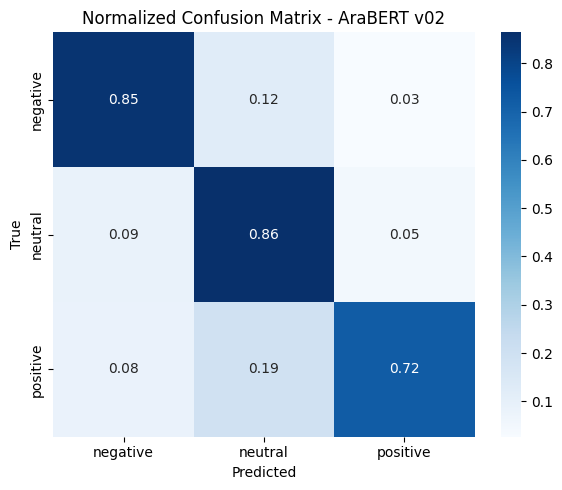

In [10]:
# --- Normalized confusion matrix (rows=true, cols=pred) ---
cm = confusion_matrix(y_true, y_pred, labels=np.arange(n_labels))
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, row_sums, where=(row_sums != 0))
plt.figure(figsize=(max(6, n_labels), max(5, n_labels*0.5)))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=[id2label[i] for i in range(n_labels)],
            yticklabels=[id2label[i] for i in range(n_labels)])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix - AraBERT v02")
plt.tight_layout()
plt.show()